# Calculating QC stats to compare with Rabbit
First FRIP for genes

In [1]:
here::i_am("processing/0_create_arrow_files.R")
source(here::here("settings.R"))
source(here::here("load_archR_project.R"))
library(viridis)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/atac/archR

Setting default genome to Mm10.

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,_

In [3]:
metadata_postQC = as.data.table(ArchRProject@cellColData)

In [4]:
paste('Median TSSEnrichment: ', median(metadata_postQC$TSSEnrichment))
paste('Median nFrags: ', median(metadata_postQC$nFrags))
paste('Median FRIP: ', round(median(metadata_postQC$FRIP),2))

[1] "Median TSSEnrichment:  16.382"

[1] "Median nFrags:  22077"

[1] "Median FRIP:  0.44"

In [5]:
median(metadata_postQC$PromoterRatio)

[1] 0.2260818

In [6]:
ArchRProject@geneAnnotation$TSS

GRanges object with 45199 ranges and 2 metadata columns:
          seqnames    ranges strand |     tx_id     tx_name
             <Rle> <IRanges>  <Rle> | <integer> <character>
      [1]     chr1   4807893      + |         1  uc007afg.1
      [2]     chr1   4857694      + |         3  uc007afi.2
      [3]     chr1   4858328      + |         5  uc011whu.1
      [4]     chr1   4884322      + |         6  uc057aty.1
      [5]     chr1   5083086      + |         7  uc007afm.2
      ...      ...       ...    ... .       ...         ...
  [45195]     chrY  89745342      - |     63557  uc029ygr.1
  [45196]     chrY  89745550      - |     63559  uc029ygt.1
  [45197]     chrY  90531635      - |     63560  uc029ygu.1
  [45198]     chrY  90605864      - |     63561  uc029ygv.1
  [45199]     chrY  90755050      - |     63562  uc057mdi.1
  -------
  seqinfo: 21 sequences from mm10 genome

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"

In [ ]:
addArchRThreads(threads = 16)
addArchRVerbose(verbose = FALSE)

In [50]:
calculate_FRIP = function(Arrow, name){
    tmp = addFeatureMatrix(Arrow, 
                 features = ArchRProject@geneAnnotation$genes,
                 matrixName = "Genes")
    
    tmp2 = as.data.table(tmp, keep.rownames=T) %>% 
         setnames('rn', 'input') %>%
        .[input!='ArrowFile'] %>% 
         .[,`:=`(stat=str_split(input, '\\.') %>% map_chr(1),
                cell=paste0(str_split(input, '\\.') %>% map_chr(2), '.', str_split(input, '\\.') %>% map_chr(3)))] %>% # long way of saying keep everything besides the stat
        .[stat=='FRIP'] %>%
        .[,c('cell', 'tmp')] %>% setnames('tmp', paste0('FRIP_', name))
    
    return(tmp2)
}

In [51]:
FRIP_genes = lapply(ArchRProject@sampleColData$ArrowFiles, calculate_FRIP, name='Gene') %>%
    rbindlist()

In [53]:
fwrite(FRIP_genes, '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/qc/genes_FRIP.txt.gz')

In [2]:
FRIP_genes = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/qc/genes_FRIP.txt.gz')

In [11]:
round(median(FRIP_genes$FRIP_Gene),2)

[1] 0.56

In [3]:
meta = as.data.table(ArchRProject@cellColData)

In [6]:
test = FRIP_genes[,sample:=str_split(cell, '#') %>% map_chr(1)] %>% 
    .[,FRIP_Gene:=as.numeric(FRIP_Gene)] %>%
    merge(., meta[,c('sample', 'stage')] %>% unique(by='sample'), by='sample') %>%
    .[,sample:=gsub('rabbit_', '', sample)] %>%
    .[!sample%in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')] 

Warning message:
“Removed 3 rows containing non-finite values (stat_boxplot).”
Warning message:
“Removed 3 rows containing missing values (geom_point).”


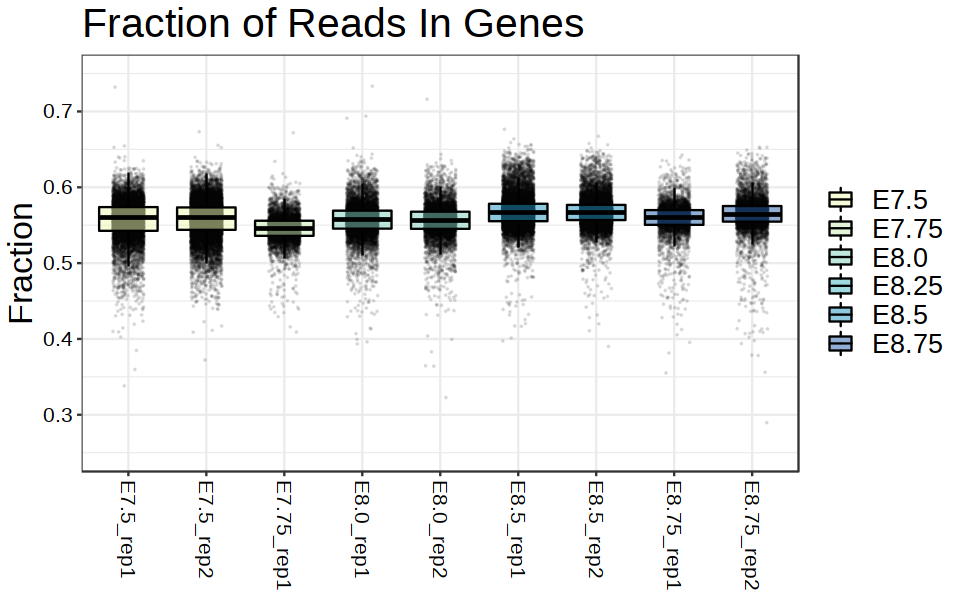

In [20]:
options(repr.plot.width=8, repr.plot.height=5)
p = ggplot(test, aes(sample, FRIP_Gene, fill=stage)) + 
  #  geom_violin() + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, col='black') +
    scale_fill_manual(values=opts$stage.colors) + 
    ylim(0.25, 0.75) +
    ggtitle('Fraction of Reads In Genes') + 
    ylab('Fraction') + 
    theme_bw() +
    theme(
            legend.position = "right",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.75), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p

In [22]:
pdf(sprintf('%s/results/atac/archR/qc/FRIG_argelaguet.pdf', io$basedir), width= 6, height=3)
    p
dev.off()

Warning message:
“Removed 3 rows containing non-finite values (stat_boxplot).”
Warning message:
“Removed 3 rows containing missing values (geom_point).”


png 
  2

# TSS score based on nearest peak of promoters

In [34]:
library(parallel)

In [35]:
# Get peakset
peakset = as.data.table(ArchRProject@peakSet) %>%
    .[peakType=='Promoter'] %>% # subset to promoters
    .[,centre:=(start+end)/2] %>% # add peak centre
    .[,tx_id:=.I] %>% # add id
    .[, tx_name:=paste0(nearestGene, '_', tx_id)] # add name

# filter by peaks closest to annotated TSS if multiple peaks (test with an without)
peakset = peakset[order(distToTSS)][distToTSS<=500] %>% unique(by='nearestGene')

## Add strand
# Strand info from TSS gives weird results because the closest TSS is not necessarily the TSS of the nearest gene, so trying with nearest gene strand instead
TSS_info = as.data.table(getTSS(ArchRProject))[,c('seqnames', 'start', 'strand', 'tx_id', 'tx_name')] %>% setnames('start', 'ranges')#[,c('tx_name', 'strand')] %>% setnames('tx_name', 'nearestTSS')
#peakset = merge(peakset[,-'strand'], TSS_info, by='nearestTSS')

strand_info = as.data.table(ArchRProject@geneAnnotation$genes)[,c('symbol', 'strand')] %>% setnames('symbol', 'nearestGene') %>% unique(by='nearestGene')
peakset = merge(peakset[,-'strand'], strand_info, by='nearestGene') %>%
    .[order(seqnames, start)] #%>% .[seqnames=='chrX']

# Add 1 chrY region to make it work, if one chr is left out ArchR gives an error :/
peakset = peakset[,c('seqnames', 'centre', 'strand', 'tx_id', 'tx_name')] %>% setnames('centre', 'ranges')
peakset = rbind(peakset, tail(TSS_info,1))

# make granges object
peakset.gr = GRanges(
    seqnames = Rle(peakset$seqnames),
    ranges = IRanges(peakset$ranges),
    strand = Rle(strand(peakset$strand)),
    tx_id = peakset$tx_id,
    tx_name = peakset$tx_name)

In [36]:
genome = as.data.table(ArchRProject@genomeAnnotation$chromSizes)

In [37]:
genome.gr = GRanges(
    seqnames = Rle(genome$seqnames),
    ranges = IRanges(genome$start+2001, genome$end-2001))

In [38]:
findOverlaps(genome.gr, peakset.gr)
# All TSS peaks fall within 2000 kb from the edges of the chromosomes

Hits object with 13227 hits and 0 metadata columns:
          queryHits subjectHits
          <integer>   <integer>
      [1]         1           1
      [2]         1           2
      [3]         1           3
      [4]         1           4
      [5]         1           5
      ...       ...         ...
  [13223]        20       13223
  [13224]        20       13224
  [13225]        20       13225
  [13226]        20       13226
  [13227]        21       13227
  -------
  queryLength: 21 / subjectLength: 13227

In [39]:
addArchRThreads(threads = 16)

TSS_scores = plotTSSEnrichment(ArchRProj = ArchRProject,
                 TSS = peakset.gr,
                 returnDF = TRUE)

Setting default number of Parallel threads to 16.



In [40]:
TSS_scores = as.data.table(TSS_scores)

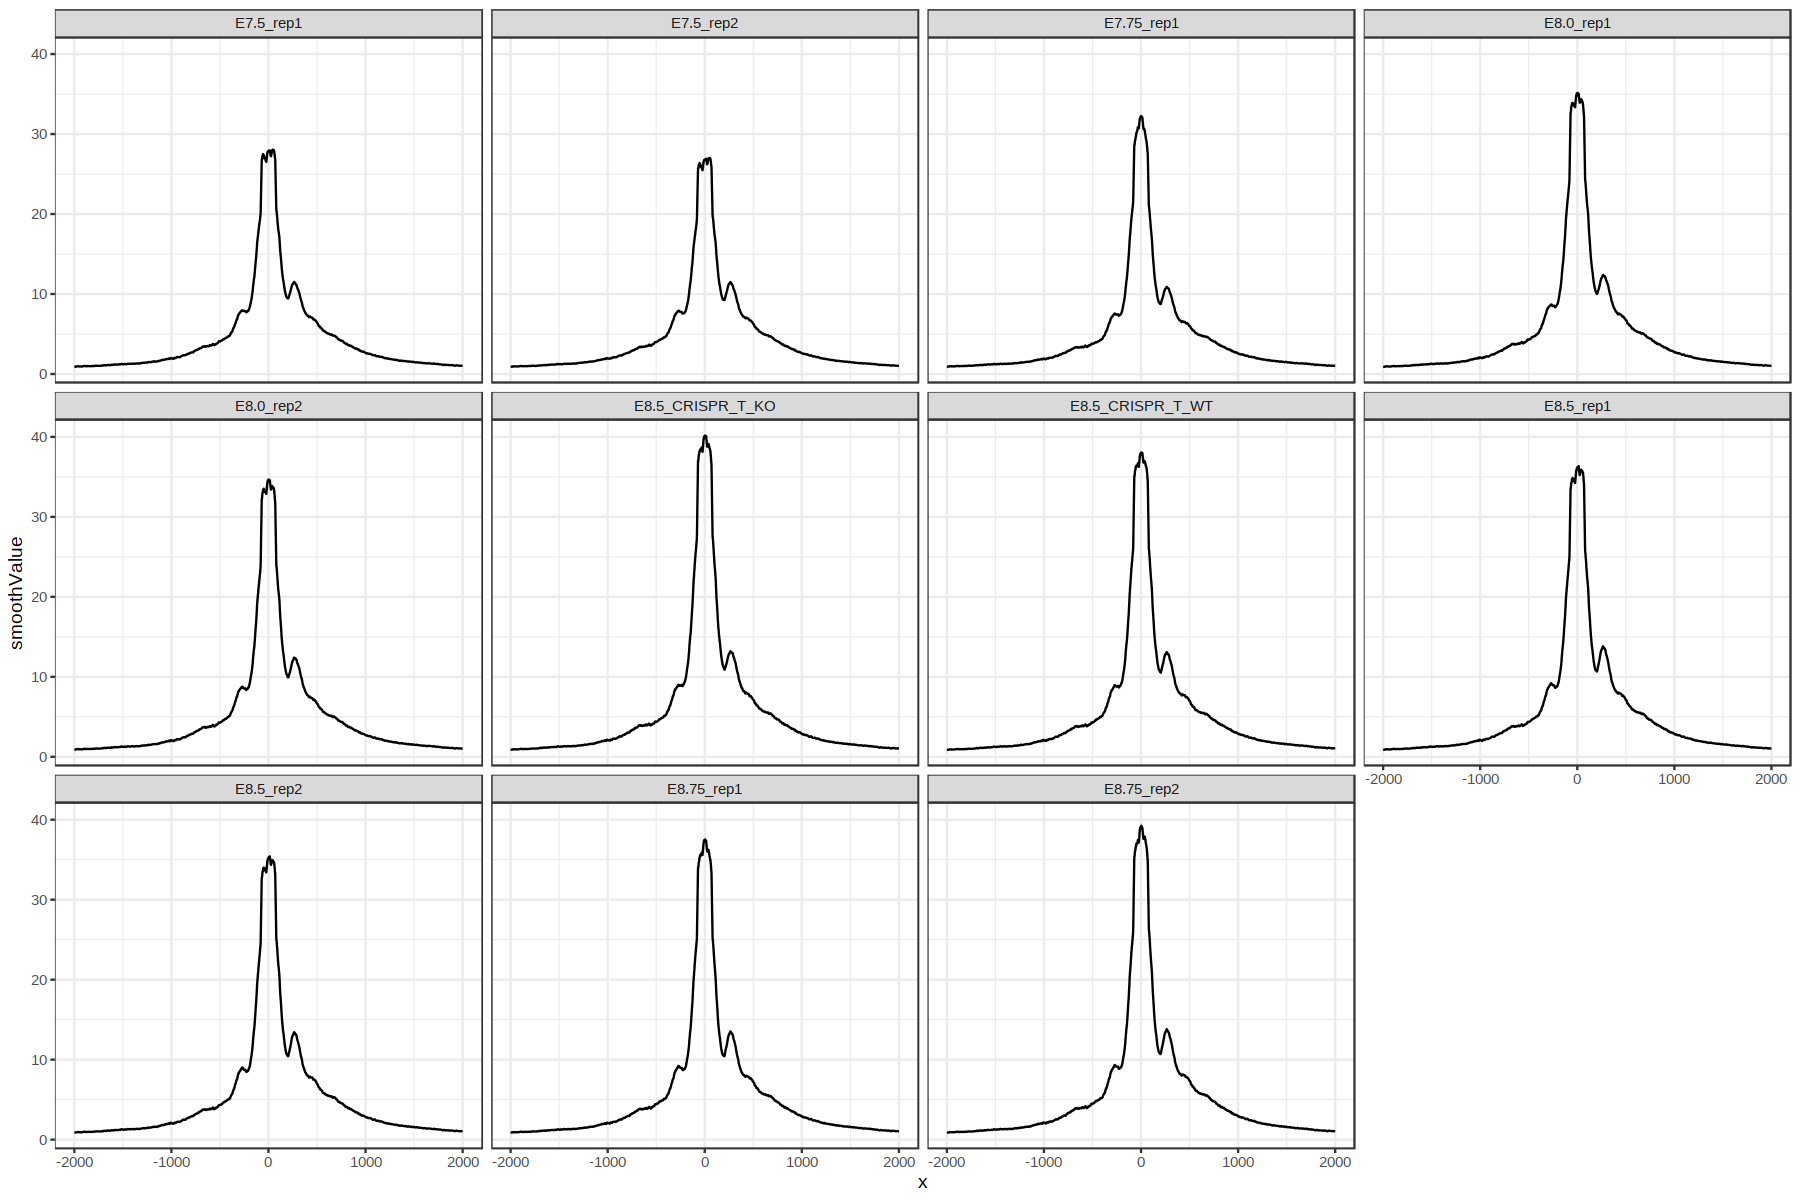

In [41]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(TSS_scores, aes(x, smoothValue)) + geom_line() + facet_wrap(~group) + theme_bw()

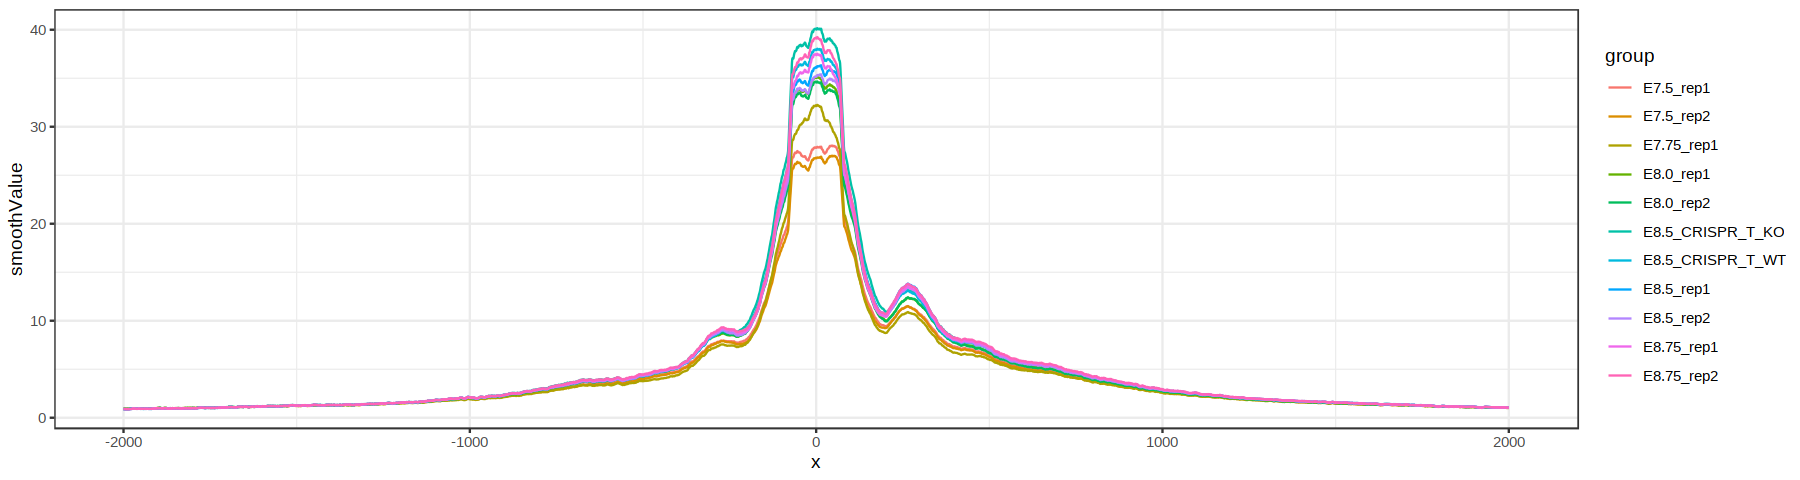

In [42]:
options(repr.plot.width=15, repr.plot.height=4)
ggplot(TSS_scores, aes(x, smoothValue, col=group)) + geom_line() + theme_bw()

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


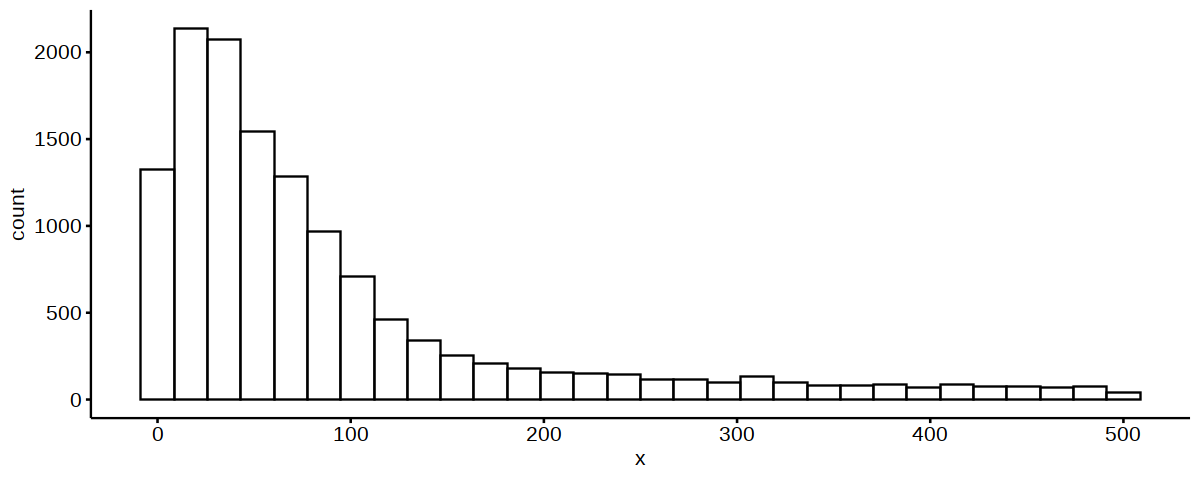

In [8]:
options(repr.plot.width=10, repr.plot.height=4)
peakset = as.data.table(ArchRProject@peakSet) %>%
    .[peakType=='Promoter'] %>% # subset to promoters
    .[,centre:=(start+end)/2] %>% # add peak centre
    .[,tx_id:=.I] %>% # add id
    .[, tx_name:=paste0(nearestGene, '_', tx_id)] # add name

# filter by peaks closest to annotated TSS if multiple peaks (test with an without)
peakset = peakset[order(distToTSS)][distToTSS<=500] %>% unique(by='nearestGene')

gghistogram(peakset$distToTSS)

In [9]:
# I think it crashes because some of the 2000 - TSS + 2000 lay outside of a chromosome
# nope

# maybe because chrY is missing

In [10]:
TSS_per_cell = mclapply(ArchRProject@sampleColData$ArrowFiles[1:9], function(Arrow){
    tmp = ArchR:::.fastTSSEnrichment(
                 TSS=peakset.gr,
                ArrowFile = Arrow)
    tmp = as.data.table(tmp$tssScores, keep.rownames=T) %>% setnames(c('cell', 'TSSscore'))
    return(tmp)
}, mc.cores=16) %>% rbindlist()

In [11]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames=T) %>% setnames('rn', 'cell') %>%  
    merge(.,TSS_per_cell, by='cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


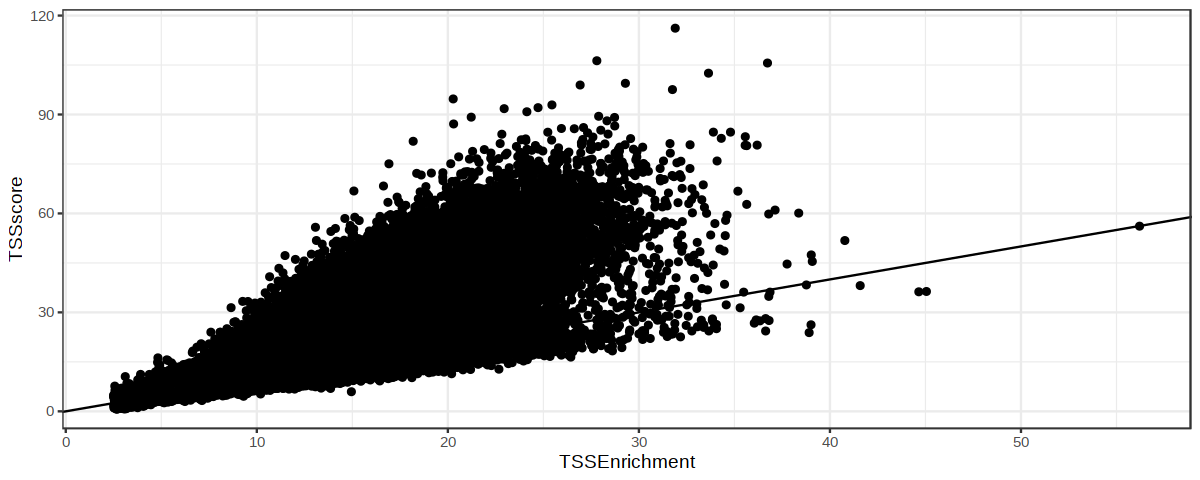

In [12]:
options(repr.plot.width=10, repr.plot.height=4)
ggplot(meta, aes(TSSEnrichment, TSSscore)) + geom_point() + geom_abline(slope=1) + theme_bw()

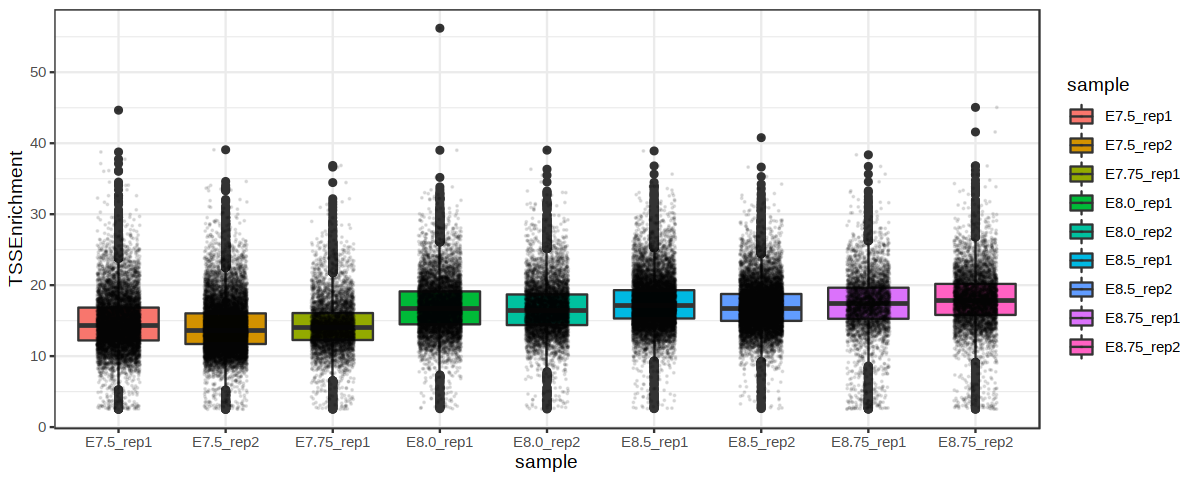

In [13]:
ggplot(meta, aes(sample, TSSEnrichment, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

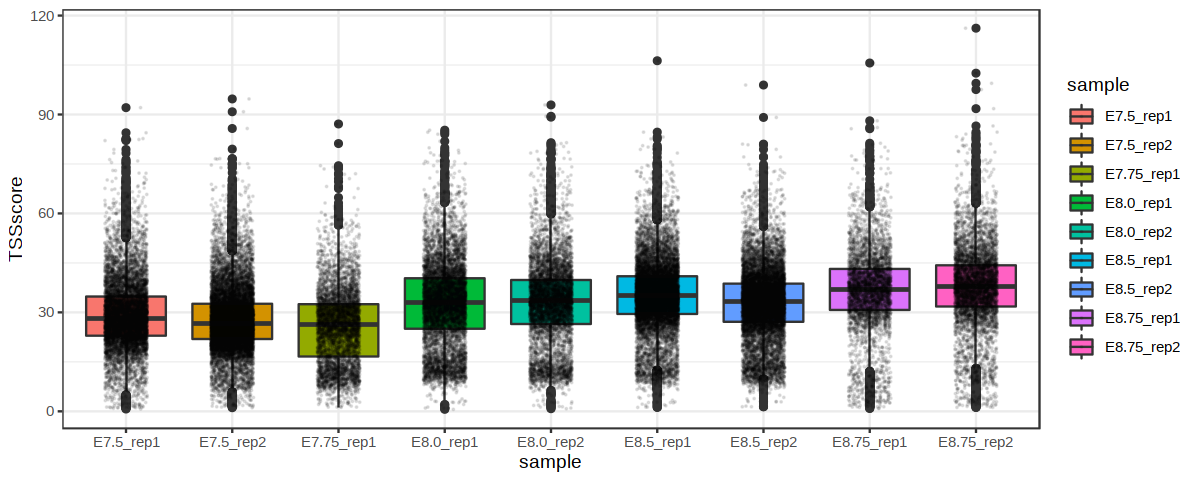

In [14]:
ggplot(meta, aes(sample, TSSscore, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

# Global peak enrichment

In [31]:
# Get peakset
peakset = as.data.table(ArchRProject@peakSet) %>%
   # .[peakType=='Promoter'] %>% # subset to promoters # skipped bc using all peaks
    .[,centre:=(start+end)/2] %>% # add peak centre
    .[,tx_id:=.I] %>% # add id
    .[, tx_name:=paste0(nearestGene, '_', tx_id)] # add name

# filter by peaks closest to annotated TSS if multiple peaks (test with an without)
#peakset = peakset[order(distToTSS)][distToTSS<=500] %>% unique(by='nearestGene')

## Add strand
# Strand info from TSS gives weird results because the closest TSS is not necessarily the TSS of the nearest gene, so trying with nearest gene strand instead
#TSS_info = as.data.table(getTSS(ArchRProject))[,c('tx_name', 'strand')] %>% setnames('tx_name', 'nearestTSS')
#peakset = merge(peakset[,-'strand'], TSS_info, by='nearestTSS')

#strand_info = as.data.table(ArchRProject@geneAnnotation$genes)[,c('symbol', 'strand')] %>% setnames('symbol', 'nearestGene') %>% unique(by='nearestGene')
#peakset = merge(peakset[,-'strand'], strand_info, by='nearestGene')

TSS_info = as.data.table(getTSS(ArchRProject))[,c('seqnames', 'start', 'strand', 'tx_id', 'tx_name')] %>% setnames('start', 'ranges')#[,c('tx_name', 'strand')] %>% setnames('tx_name', 'nearestTSS')
# Add 1 chrY region to make it work, if one chr is left out ArchR gives an error :/
peakset = peakset[,c('seqnames', 'centre', 'strand', 'tx_id', 'tx_name')] %>% setnames('centre', 'ranges')
peakset = rbind(peakset, tail(TSS_info,1))

# make granges object
peakset.gr = GRanges(
    seqnames = Rle(peakset$seqnames),
    ranges = IRanges(peakset$ranges),
    strand = Rle(strand(peakset$strand)),
    tx_id = peakset$tx_id,
    tx_name = peakset$tx_name)

In [32]:
peakset.gr

GRanges object with 192252 ranges and 2 metadata columns:
           seqnames    ranges strand |     tx_id              tx_name
              <Rle> <IRanges>  <Rle> | <integer>          <character>
       [1]     chr1   3035902      * |         1               Xkr4_1
       [2]     chr1   3062953      * |         2               Xkr4_2
       [3]     chr1   3072613      * |         3               Xkr4_3
       [4]     chr1   3191796      * |         4               Xkr4_4
       [5]     chr1   3340875      * |         5               Xkr4_5
       ...      ...       ...    ... .       ...                  ...
  [192248]     chrX 169906221      * |    192248 4933400A11Rik_192248
  [192249]     chrX 169915916      * |    192249 4933400A11Rik_192249
  [192250]     chrX 169925787      * |    192250 4933400A11Rik_192250
  [192251]     chrX 169937364      * |    192251 4933400A11Rik_192251
  [192252]     chrY  90755050      - |     63562           uc057mdi.1
  -------
  seqinfo: 21 sequence

In [27]:
addArchRThreads(threads = 16)

TSS_scores = plotTSSEnrichment(ArchRProj = ArchRProject,
                 TSS = peakset.gr,
                 returnDF = TRUE)

Setting default number of Parallel threads to 16.



In [28]:
TSS_scores = as.data.table(TSS_scores)

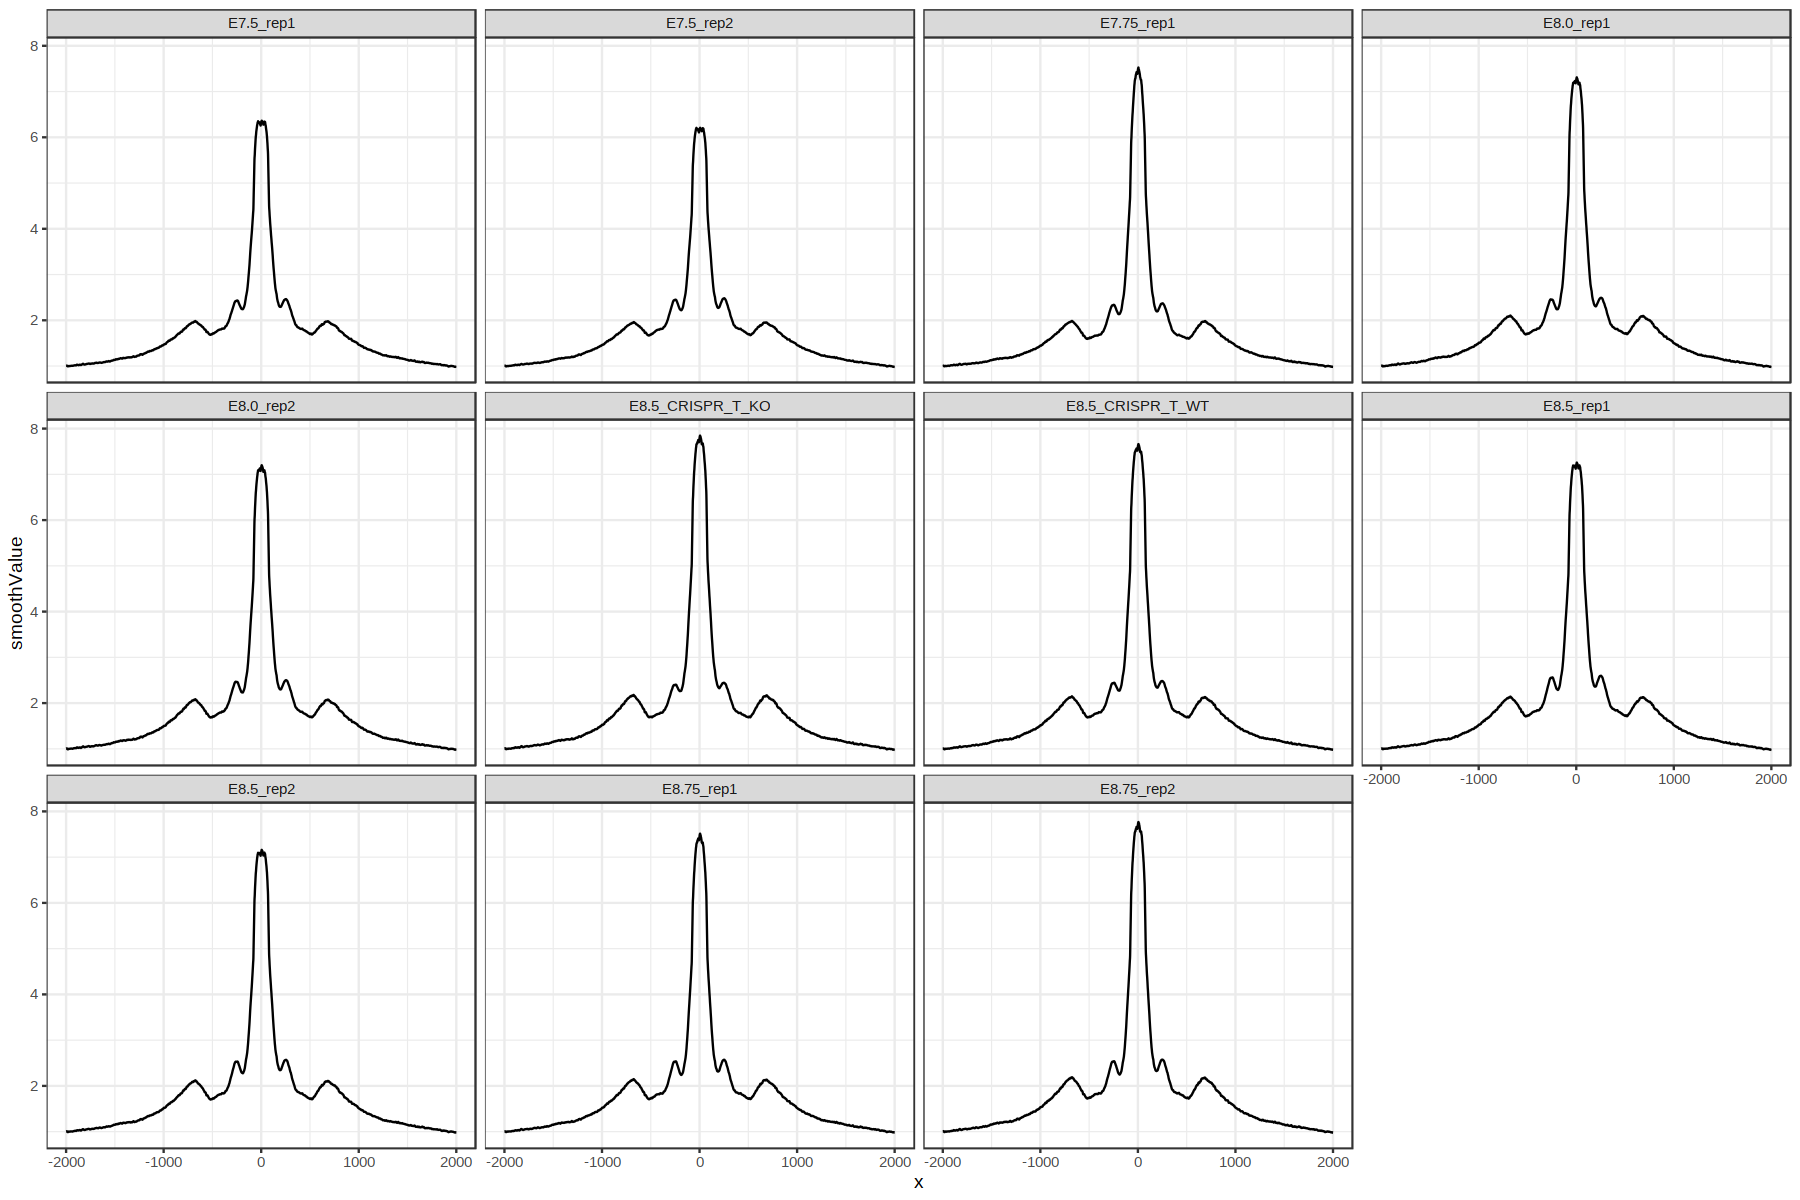

In [29]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(TSS_scores, aes(x, smoothValue)) + geom_line() + facet_wrap(~group) + theme_bw()

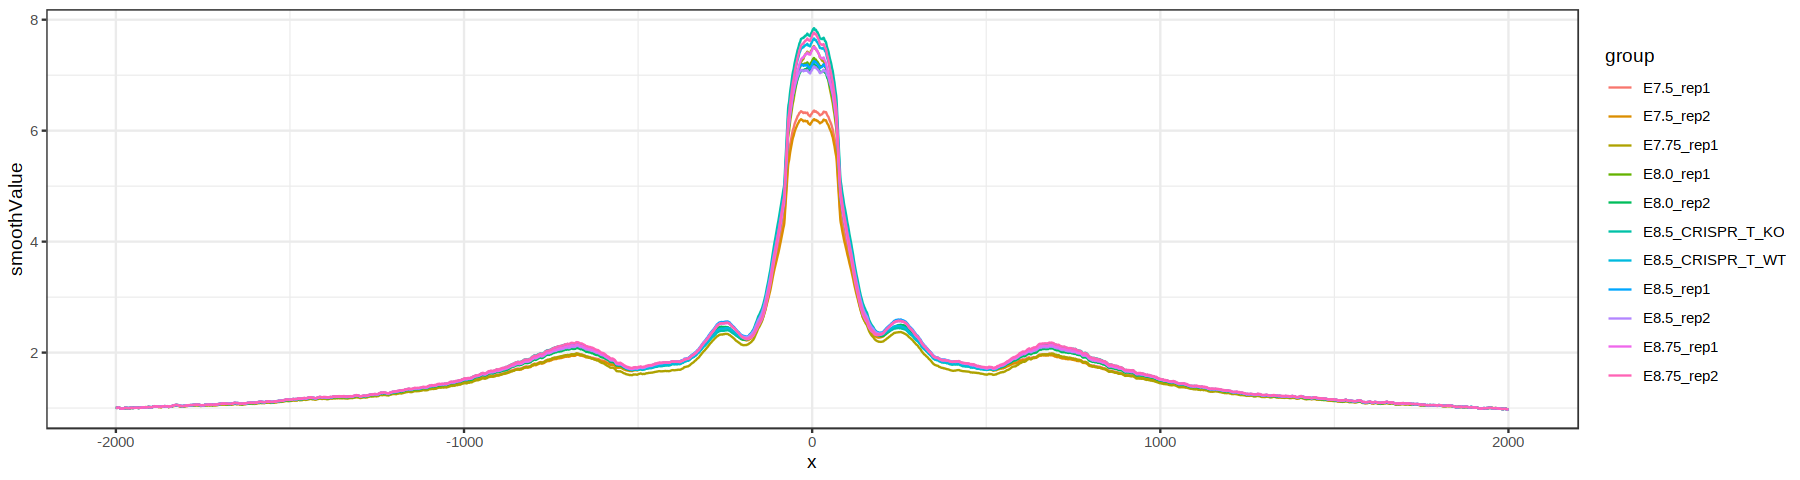

In [30]:
options(repr.plot.width=15, repr.plot.height=4)
ggplot(TSS_scores, aes(x, smoothValue, col=group)) + geom_line() + theme_bw()

In [ ]:
# Determine TSS enrichment with those peaks at per cell level

In [22]:
TSS_per_cell = mclapply(ArchRProject@sampleColData$ArrowFiles, function(Arrow){
    tmp = ArchR:::.fastTSSEnrichment(
                 TSS=peakset.gr,
                ArrowFile = Arrow)
    tmp = as.data.table(tmp$tssScores, keep.rownames=T) %>% setnames(c('cell', 'TSSscore'))
}, mc.cores=16) %>% rbindlist()

In [23]:
meta = as.data.table(ArchRProject@cellColData, keep.rownames=T) %>% setnames('rn', 'cell') %>% 
    merge(.,TSS_per_cell, by='cell')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


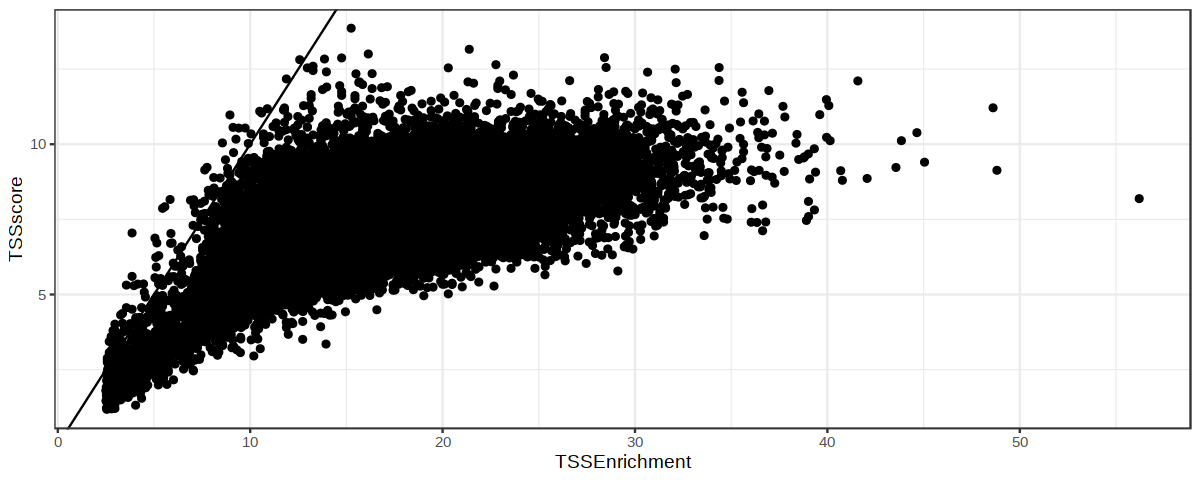

In [24]:
options(repr.plot.width=10, repr.plot.height=4)
ggplot(meta, aes(TSSEnrichment, TSSscore)) + geom_point() + geom_abline(slope=1) + theme_bw()

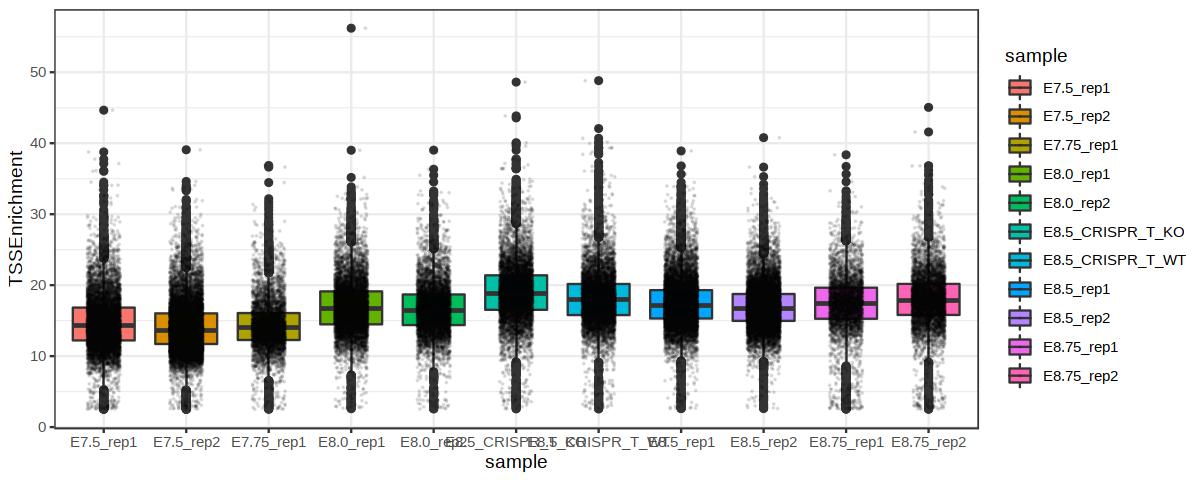

In [25]:
ggplot(meta, aes(sample, TSSEnrichment, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()

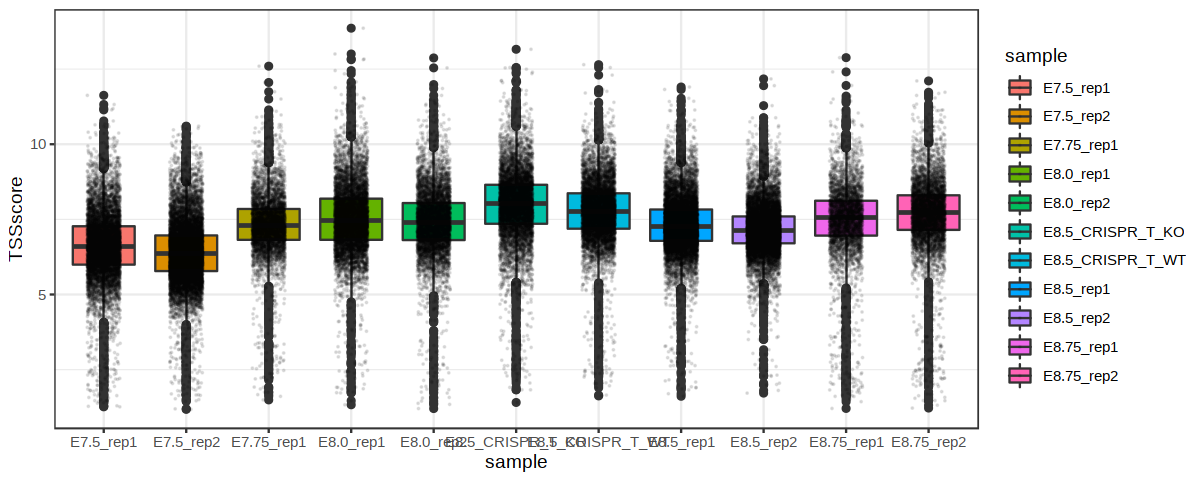

In [26]:
ggplot(meta, aes(sample, TSSscore, fill=sample)) + geom_boxplot(alpha=1) + geom_point(position=position_jitter(width=0.2), size=0.05, alpha=0.1)  + theme_bw()